# Language Model for the Shakespeare Dataset

The idea of this project is use text preprocessing tools and RNN models to build a character-level language model. Train the model on the works of Shakespeare and use the network to generate own text.

In [1]:
# Package Imports

import tensorflow as tf
import numpy as np
import json
import matplotlib.pyplot as plt
%matplotlib inline

##
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.data import Dataset

from tensorflow.keras.layers import Embedding, GRU, RNN, Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.losses import SparseCategoricalCrossentropy


![imagen-shakespeare](data/shakespeare.png)

## The Shakespeare Dataset

We will work with a subset of the [Shakespeare dataset](http://shakespeare.mit.edu). It consists of a single text file with severeal excerpts concatenated together. The data is in a row text form and so far has not yet had any preprocessing. 

Therefore, the goal is construct an unsupervised character-level sequence model that can generate text according to a distribution learned from the dataset

### Loanding and Inspecting the Dataset

In [2]:
# Load text file into a string

with open('data/Shakespeare.txt', 'r', encoding='utf-8') as file:
    text = file.read()


In [3]:
#Printing 1000 letters of the string text

text[:1000]

"First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for the gods know I\nspeak this in hunger 

In [4]:
# Creating a list of chunks of text
# We separate the sentences

text_chunks = text.split('.') 


In [5]:
# Looking the first 10 chunks
text_chunks[:10]


['First Citizen:\nBefore we proceed any further, hear me speak',
 '\n\nAll:\nSpeak, speak',
 '\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved',
 ' resolved',
 '\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people',
 "\n\nAll:\nWe know't, we know't",
 "\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price",
 "\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens",
 '\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good',
 '\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for t

Looking few chunks from the list in random order

In [6]:
num_samples = 10
idx = np.random.choice(len(text_chunks), num_samples, replace=False)
for chunck in np.array(text_chunks)[idx]:
    print(chunck)



PAULINA:
So much the more our carver's excellence;
Which lets go by some sixteen years and makes her
As she lived now

These, as I learn, and such like toys as these
Have moved his highness to commit me now


DUKE VINCENTIO:
Hath he born himself penitently in prison? how
seems he to be touched?

Provost:
A man that apprehends death no more dreadfully but
as a drunken sleep; careless, reckless, and fearless
of what's past, present, or to come; insensible of
mortality, and desperately mortal


LUCENTIO:
I thank thee for that gird, good Tranio


RIVERS:
My Lord of Gloucester, in those busy days
Which here you urge to prove us enemies,
We follow'd then our lord, our lawful king:
So should we you, if you should be our king
 Hark! what noise is this?

QUEEN ELIZABETH:
Oh, who shall hinder me to wail and weep,
To chide my fortune, and torment myself?
I'll join with black despair against my soul,
And to myself become an enemy


CLAUDIO:
I humbly thank you


DUKE OF YORK:
It was, villain, ere

## Creating a character-level tokenizer

In [7]:

def create_character_tokenizer(list_of_strings):

    tokenizer = Tokenizer(
        num_words=None,
        filters='',
        lower= False,
        char_level = True,
        oov_token='<UNK>',
    )
    tokenizer.fit_on_texts(list_of_strings)
    return tokenizer




In [8]:
#Getting the tokenizer

tokenizer = create_character_tokenizer(text_chunks)


In [9]:
tokenizer_config = tokenizer.get_config()
print(tokenizer_config)
print(tokenizer_config.keys())
print(tokenizer_config['word_counts'])

{'num_words': None, 'filters': '', 'lower': False, 'split': ' ', 'char_level': True, 'oov_token': '<UNK>', 'document_count': 7886, 'word_counts': '{"F": 1797, "i": 45537, "r": 48889, "s": 49696, "t": 67009, " ": 169892, "C": 3820, "z": 356, "e": 94611, "n": 48529, ":": 10316, "\\n": 40000, "B": 2761, "f": 15770, "o": 65798, "w": 17585, "p": 10808, "c": 15623, "d": 31358, "a": 55507, "y": 20448, "u": 26584, "h": 51310, ",": 19846, "m": 22243, "k": 7088, "A": 7819, "l": 33339, "S": 4523, "Y": 1718, "v": 7793, "?": 2462, "R": 4869, "M": 2840, "W": 3530, "\'": 6187, "L": 3876, "I": 11832, "N": 5079, "g": 13356, ";": 3628, "b": 11321, "!": 2172, "O": 5481, "j": 628, "V": 798, "-": 1897, "T": 7015, "H": 3068, "E": 6041, "U": 3313, "D": 2089, "P": 1641, "q": 609, "x": 529, "J": 320, "G": 2399, "K": 1584, "Q": 231, "&": 3, "Z": 198, "X": 112, "3": 27, "$": 1}', 'word_docs': '{":": 6460, "p": 4562, "n": 7229, "u": 6580, "z": 310, "a": 7414, "h": 7282, "m": 6454, " ": 7866, "B": 2146, "s": 7260,

### Tokenize the text

In [10]:


def strings_to_sequences(tokenizer, list_of_strings):

    sentence_sequence = tokenizer.texts_to_sequences(list_of_strings)

    return sentence_sequence


In [11]:
seq_chunks = strings_to_sequences(tokenizer, text_chunks)

In [12]:
print(len(seq_chunks))
print(len(seq_chunks[0]))
print(seq_chunks[0])


7886
59
[50, 11, 9, 8, 4, 2, 38, 11, 4, 11, 58, 3, 10, 26, 12, 44, 3, 20, 5, 9, 3, 2, 19, 3, 2, 25, 9, 5, 21, 3, 3, 14, 2, 6, 10, 17, 2, 20, 15, 9, 4, 7, 3, 9, 18, 2, 7, 3, 6, 9, 2, 16, 3, 2, 8, 25, 3, 6, 29]


### Padding the encoded sequences and store them in a numpy array

In [13]:


def make_padded_dataset(sequence_chunks):

    sequence_padded = pad_sequences(sequence_chunks,
                                    maxlen=500,
                                    padding='pre',
                                    truncating='pre',
                                    value=0)

    return sequence_padded

In [14]:
#Padding the token sequence chunks and getting the numpy array

padded_sequences = make_padded_dataset(seq_chunks)



In [15]:
print(padded_sequences.shape)
print(padded_sequences[55])



(7886, 500)
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0

## Creating the model inputs and targets

The idea is build an RNN model. The model will receive a sequence of characters and predict the next character in the sequence. At training time, the model can be passed an input sequence, with the target sequence is shifted by one. 

For example, the expression `To be or not to be` appears in Shakespeare's play 'Hamlet'. Given input `To be or not to b`, the correct prediction is `o be or not to be`. The prediction is the same length as the input.

![image-example](data/rnn_example.png)

In [16]:


def create_inputs_and_targets(array_of_sequences):

    input_array = array_of_sequences[:, :-1]
    output_array = array_of_sequences[:, 1:]

    return (input_array, output_array)



In [17]:
# Input and output arrays

input_seq, target_seq = create_inputs_and_targets(padded_sequences)



### Preprocess Sequence array for Stateful RNN

The idea is build a RNN Language model to be stateful, so that the internal state of the RNN will be maintained across batches. 

In [18]:

#Batch size for training

batch_size = 32


In [19]:

#Preparing the input and output arrays for training stateful RNN

num_examples = input_seq.shape[0]

num_processed_examples = num_examples - (num_examples % batch_size)

input_seq = input_seq[:num_processed_examples]
target_seq = target_seq[:num_processed_examples]

steps = int(num_processed_examples / 32)

idx = np.empty((0,), dtype=np.int32)
for i in range(steps):
    idx = np.concatenate((idx, i + np.arange(0, num_processed_examples, steps)))


input_seq_stateful = input_seq[idx]
target_seq_stateful = target_seq[idx]


### Splitting the data into training an validation sets

In [20]:


num_train_examples = int(batch_size * ((0.8 * num_processed_examples) // batch_size))

input_train = input_seq_stateful[:num_train_examples]
target_train = target_seq_stateful[:num_train_examples]

input_valid = input_seq_stateful[num_train_examples:]
target_valid = target_seq_stateful[num_train_examples:]


### Creating training and validation Dataset objects

In [21]:

def make_Dataset(input_array, target_array, batch_size):

    dataset = Dataset.from_tensor_slices((input_array, target_array))

    dataset = dataset.batch( batch_size=batch_size, 
                            drop_remainder=True)

    return dataset


In [22]:

train_data = make_Dataset(input_train, target_train, batch_size)
valid_data = make_Dataset(input_valid, target_valid, batch_size)



## Building the recurrent neural network

In [23]:

def get_model(vocab_size, batch_size):

    model = Sequential([
        Input(batch_shape=(batch_size, None)),
        Embedding(vocab_size, 256, mask_zero=True),
        GRU(units=1024, stateful=True, return_sequences=True),
        Dense(units=vocab_size)
    ])

    return model
    

In [24]:


model = get_model(len(tokenizer.word_index) + 1, batch_size)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, None, 256)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (32, None, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, None, 66)         │        67,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,022,850 (15.35 MB)

 Trainable params: 4,022,850 (15.35 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling and Training the Model


In [25]:

skip_training =  True

In [26]:

if not skip_training:
    checkpoint_callback = ModelCheckpoint(filepath='./models/ckpt.weights.h5',
                                            save_weights_only=True,
                                            save_best_only=True)

    model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['sparse_categorical_accuracy'])
    history = model.fit(train_data, epochs=15, validation_data=valid_data,
                        validation_steps=50, callbacks=[checkpoint_callback])

In [27]:
#Saving the model history as a json file or load it if using pre-trained weights

if not skip_training:
    history_dict = dict()
    for k, v in history.history.items():
        history_dict[k] = [float(val) for val in history.history[k]]
    with open('models/history.json', 'w+') as json_file:
        json.dump(history_dict, json_file, sort_keys=True, indent=4)
else:
    with open('models/history.json', 'r') as json_file:
        history_dict = json.load(json_file)

### Plotting the Learning Curves

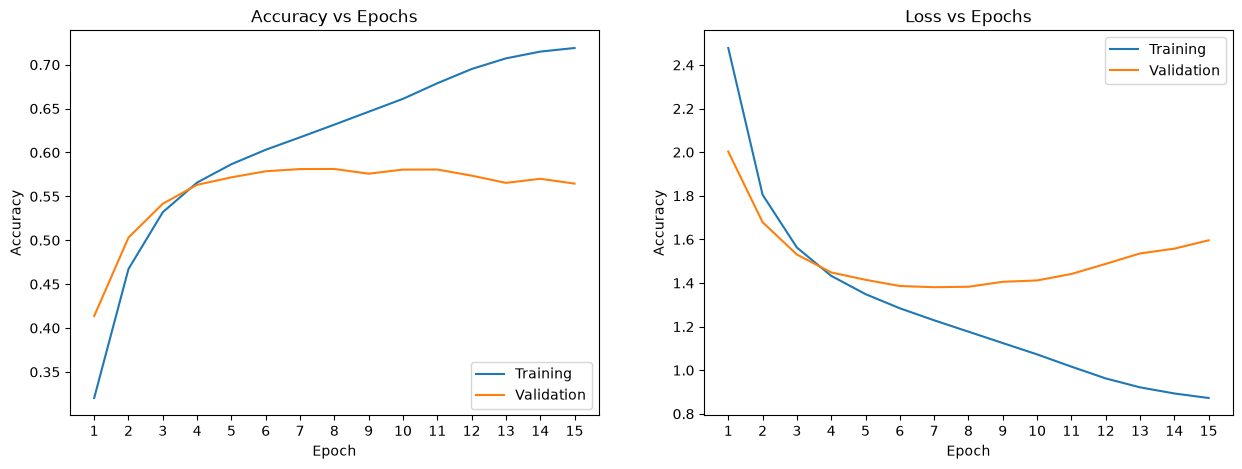

In [28]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history_dict['sparse_categorical_accuracy'])
plt.plot(history_dict['val_sparse_categorical_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(np.arange(len(history_dict['sparse_categorical_accuracy'])))
ax = plt.gca()
ax.set_xticklabels(1 + np.arange(len(history_dict['sparse_categorical_accuracy'])))
plt.legend(['Training', 'Validation'], loc='lower right')
plt.subplot(122)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Loss vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(np.arange(len(history_dict['sparse_categorical_accuracy'])))
ax = plt.gca()
ax.set_xticklabels(1 + np.arange(len(history_dict['sparse_categorical_accuracy'])))
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

## Writting the Text Generation Algorithm

In [29]:
model = get_model(len(tokenizer.word_index) + 1, batch_size=1)
model.load_weights('./models/ckpt.weights.h5')

In [30]:

model.layers[1].states

ListWrapper([<Variable path=sequential_1/gru_1/rnn_state, shape=(1, 1024), dtype=float32, value=[[0. 0. 0. ... 0. 0. 0.]]>])

In [34]:


def get_logits(model, token_sequence, initial_state=None):

    tensor_sequence_input = tf.convert_to_tensor(
        token_sequence, dtype=tf.int32
    )

    embedding_layer = model.layers[0]
    gru_layer = model.layers[1]
    output_layer = model.layers[2]

    x = embedding_layer(tensor_sequence_input)
    gru_output = gru_layer(x, initial_state=initial_state)
    predictions = output_layer(gru_output)

    logits = predictions[:, -1, :]

    return logits.numpy()

In [35]:

dummy_initial_state = tf.random.normal(model.layers[1].states[0].shape)
get_logits(model, [[1, 2, 3, 4]], initial_state = dummy_initial_state)

array([[-8.563111  , -7.3825703 ,  1.9350752 ,  5.4710674 ,  6.0525894 ,
         2.206185  ,  5.0189524 ,  5.776643  ,  3.9317036 ,  6.4247065 ,
         1.0133258 ,  4.6501403 ,  3.531117  , -0.43056086, -1.1471436 ,
         3.1716223 ,  0.81393015,  3.101127  ,  1.7113204 ,  3.9596496 ,
         1.6810064 ,  2.8062541 , -1.923907  , -2.608568  , -0.0271121 ,
        -1.845992  ,  3.5821216 , -3.2200077 , -1.3147725 , -4.96807   ,
        -4.528573  , -1.7899    , -4.927011  , -6.210948  , -5.634552  ,
        -2.6475072 , -4.997909  , -5.0422974 , -4.015238  ,  0.73023957,
        -2.079217  , -5.6305857 , -2.6640096 , -6.764606  , -2.5353057 ,
         2.2323577 , -7.592978  ,  1.1217346 , -9.434876  , -3.239972  ,
        -4.3738894 , -4.7284985 , -5.4797606 , -9.099762  , -7.5047507 ,
        -1.1326511 , -0.7744715 , -9.013179  , -6.1694913 , -6.71275   ,
        -6.998783  , -4.128717  , -7.9341426 , -9.89176   , -4.9082155 ,
        -8.8387165 ]], dtype=float32)

In [36]:


def sample_token(logits):

    logits_tensor = tf.convert_to_tensor(logits, dtype=tf.float32)

    prediction = tf.random.categorical(logits_tensor, num_samples= 1)

    return int(prediction[0,0].numpy())


In [37]:

dummy_initial_state = tf.random.normal(model.layers[1].states[0].shape)
dummy_logits = get_logits(model, [[1, 2, 3, 4]], initial_state = dummy_initial_state)
sample_token(dummy_logits)


11

In [38]:

logits_size = dummy_logits.shape[1]
dummy_logits = -np.inf*np.ones((1, logits_size))
dummy_logits[0, 20] = 0
sample_token(dummy_logits)
random_inx = np.random.choice(logits_size, 2, replace=False)
random_inx1, random_inx2 = random_inx[0], random_inx[1]
print(random_inx1, random_inx2)
dummy_logits = -np.inf*np.ones((1, logits_size))
dummy_logits[0, random_inx1] = 0
dummy_logits[0, random_inx2] = 0
sampled_token = []
for _ in range(100):
    sampled_token.append(sample_token(dummy_logits))
    
l_tokens, l_counts = np.unique(np.array(sampled_token), return_counts=True)
len(l_tokens) == 2


19 35


True

## Generating text from the model

In [39]:

#Creating a seed string and number of generation steps
init_string = 'ROMEO:'
num_generation_steps = 1000


In [40]:
# Using the model to generate a token sequence

token_sequence = tokenizer.texts_to_sequences([init_string])
initial_state = None
input_sequence = token_sequence

for _ in range(num_generation_steps):
    logits = get_logits(model, input_sequence, initial_state=initial_state)
    sampled_token = sample_token(logits)
    token_sequence[0].append(sampled_token)
    input_sequence = [[sampled_token]]
    initial_state = model.layers[1].states[0].numpy()


print(tokenizer.sequences_to_texts(token_sequence)[0][::2])




ROMEO:
Why, here all my celestare at shaken in heaven
Than
Thither, and your penforce you pardon her, he's it to be
The Marcius, when when my wife and buy for pray
Than this is Morbany' law's a baw come to Parman

CORIOLANUS:
Nay, my Doth french a way to fair daunt,
When he is Liciod, leave mount i' the crawn
A taughter and to make the squellemanage:
Is all the peace would ne'er as I can leat

SIIN ANGELE:
He is can by away: will my bower upon her one:
The geeds is loathman beat Our happy is: of garneal,
Than when you's came to have shunders the grave where
If your worshime were into heary begon There?
And, kin, they must enter that the vial and men's
Ampetian that I shall do lember mercy
And perrarly much: for I should be found your face;
But for the vipity, who, 'I'll tell you, go with the infurrent in again,
Had that full of good titings from the enemy
Is builded daughter,; she's a word and hands; after he
will, confixed, I pay me?

PRINCE:
If that my Edward lide, I do a ralfor'd no

In [41]:
#Initializing with other seed:
init_string = 'DIEGO'
num_generation_steps = 1000


In [42]:
token_sequence = tokenizer.texts_to_sequences([init_string])
initial_state = None
input_sequence = token_sequence

for _ in range(num_generation_steps):
    logits = get_logits(model, input_sequence, initial_state=initial_state)
    sampled_token = sample_token(logits)
    token_sequence[0].append(sampled_token)
    input_sequence = [[sampled_token]]
    initial_state = model.layers[1].states[0].numpy()


print(tokenizer.sequences_to_texts(token_sequence)[0][::2])


DIEGO My husband,
Where it be about, my Lord Lord camulem,
It seems their looks and say what a trade'
And now it not? O my hand nobly she As no harb,
Or whose hand-banith, a quick-kind, E'll play for her!
Plantain'd the queen, fair man that thousand loves me lead;
Of whatficine her man's place and recortable,
And beauty, I, now and moved, my liege, I am sorry,
There is no man bear in gracious most stay of nor;
This case amacuetifuler; here is anvoice
Ill do unless a light's life and death to trick
Than pagan and more feigned oney buzity
Tyat would heeded and all to my wife and
The prince det thee in my brovieding: who hair
Apposing Montague, and in the procestalions;
If you should not lie, ne'er say unto a comm?

HONTENSIO:
Stay you, Tybalt;
And there is a forward wife with you,
With stanks as the news, that drinks of green ofe of anised
Ay, but the pearce at the grief what the petterlay
Of no man is dead, an hois Buposed,
But the necessity Marcius to our king!
By arry eye to himself R